In [ ]:
from google.colab import files
uploaded = files.upload()

Saving india city aqi.csv to india city aqi.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(list(uploaded.keys())[0])

df.columns = df.columns.str.strip().str.lower()

df.head()

,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,01-01-2015,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,02-01-2015,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,03-01-2015,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,04-01-2015,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,05-01-2015,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory


In [ ]:
df = df.drop(
    columns=["city","date","country","region","aqi_category"],
    errors="ignore"
)

df = df.select_dtypes(include=np.number)

df = df.fillna(df.median())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pm25    32870 non-null  float64
 1   pm10    32870 non-null  float64
 2   no2     32870 non-null  float64
 3   so2     32870 non-null  float64
 4   co      32870 non-null  float64
 5   o3      32870 non-null  float64
 6   aqi     32870 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 1.8 MB


In [ ]:
# Remove outliers using IQR
for col in ["pm25","pm10","aqi"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1

    lower = q1-1.5*iqr
    upper = q3+1.5*iqr

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [ ]:
X = df[["pm25","pm10"]]
y = df["aqi"]

In [ ]:
from sklearn.model_selection import train_test_split

# 80% train+val , 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Split 80% into 64% train and 16% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42
)

print("Training:",len(X_train))
print("Validation:",len(X_val))
print("Testing:",len(X_test))

Training: 20928
Validation: 5233
Testing: 6541


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=25,
    min_samples_leaf=15,
    random_state=42
)

model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=15, min_samples_split=25,
                      random_state=42)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

# Validation
val_pred = model.predict(X_val)
val_r2 = r2_score(y_val, val_pred)

print(f"Validation Accuracy: {val_r2*100:.2f}%")

Validation Accuracy: 96.69%


In [ ]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test Accuracy: {r2*100:.2f}%")
print(f"RMSE: {rmse:.2f}")

Test Accuracy: 96.61%
RMSE: 5.74


In [ ]:
# Cross Validation
scores = cross_val_score(
    model,
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring="r2"
)

print("CV Scores:", [f"{score:.2f}" for score in scores])
print(f"Mean CV Accuracy: {scores.mean()*100:.2f}%")

CV Scores: ['0.97', '0.97', '0.97', '0.97', '0.97']
Mean CV Accuracy: 96.70%


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("Accuracy:", r2*100,"%")

R2 Score: 0.9660580519119756
Accuracy: 96.60580519119756 %


In [ ]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
val_r2 = r2_score(y_val, val_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Training R2: {train_r2:.2f}")
print(f"Validation R2: {val_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

print(f"Training Accuracy: {train_r2*100:.2f}%")
print(f"Validation Accuracy: {val_r2*100:.2f}%")
print(f"Test Accuracy: {test_r2*100:.2f}%")

Training R2: 0.97
Validation R2: 0.97
Test R2: 0.97
Training Accuracy: 96.85%
Validation Accuracy: 96.69%
Test Accuracy: 96.61%


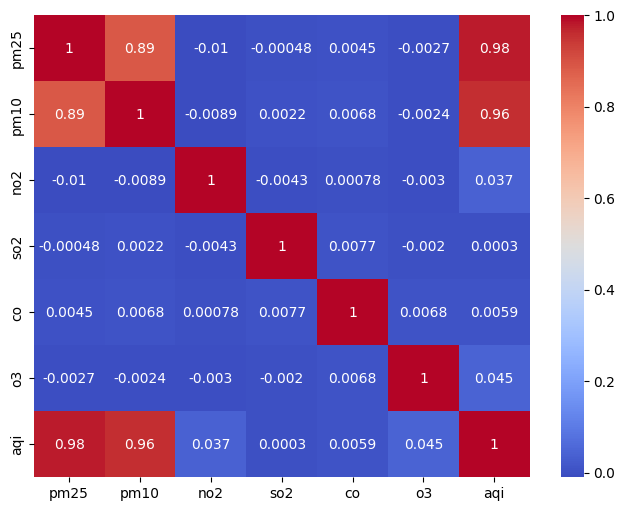

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

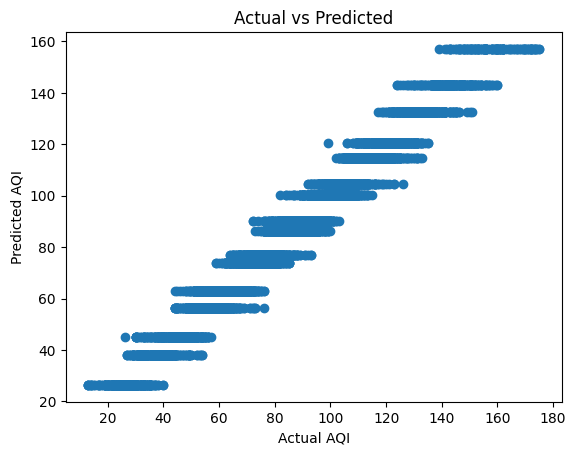

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted")
plt.show()

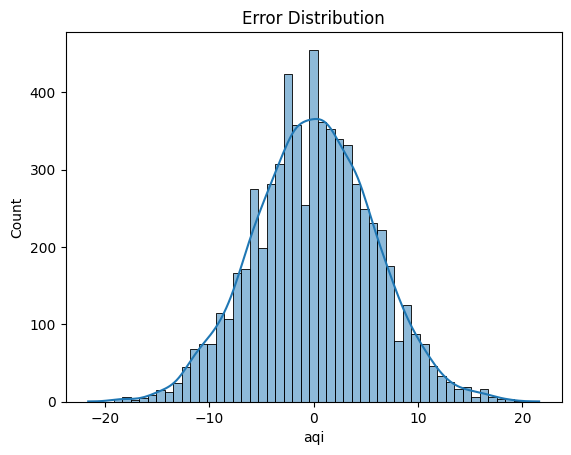

In [ ]:
errors = y_test-y_pred

sns.histplot(errors,kde=True)
plt.title("Error Distribution")
plt.show()

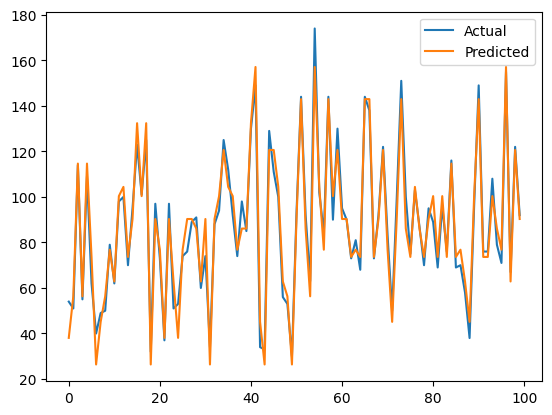

In [ ]:
plt.plot(y_test.values[:100],label="Actual")
plt.plot(y_pred[:100],label="Predicted")
plt.legend()
plt.show()

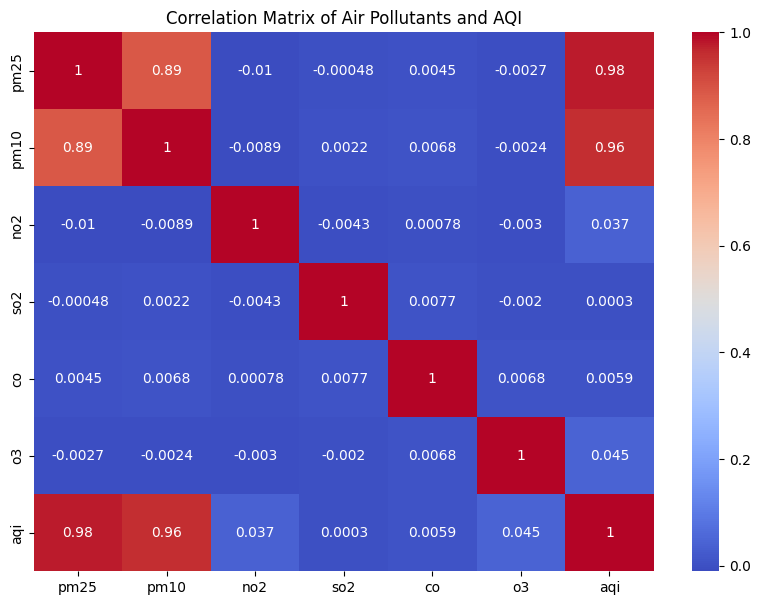

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Air Pollutants and AQI")
plt.show()

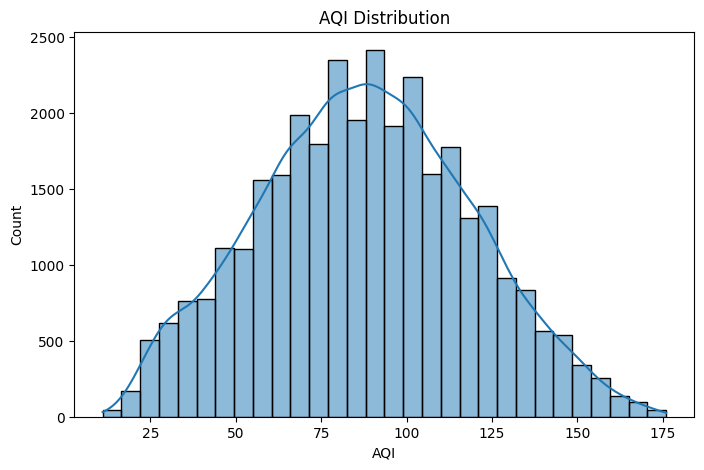

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["aqi"], bins=30, kde=True)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.show()

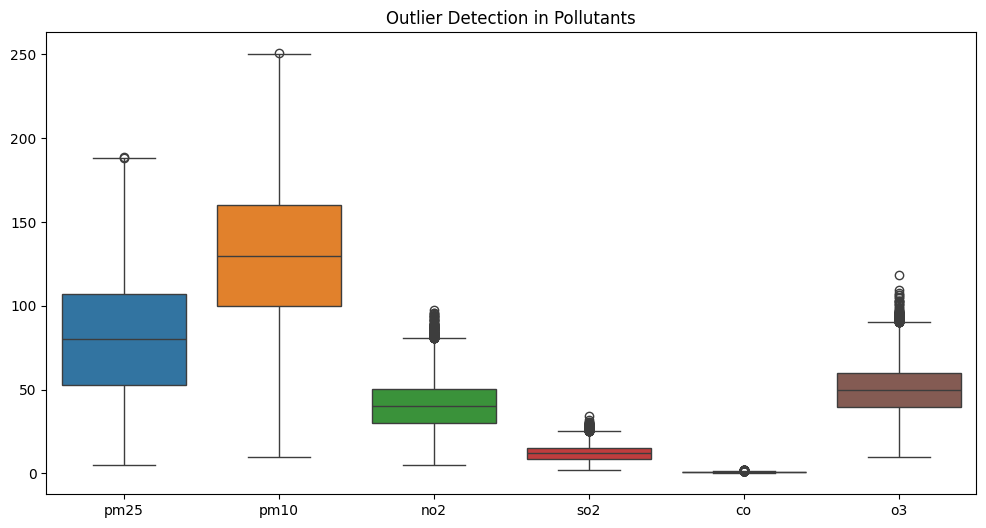

In [ ]:
pollutants=["pm25","pm10","no2","so2","co","o3"]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[pollutants])
plt.title("Outlier Detection in Pollutants")
plt.show()

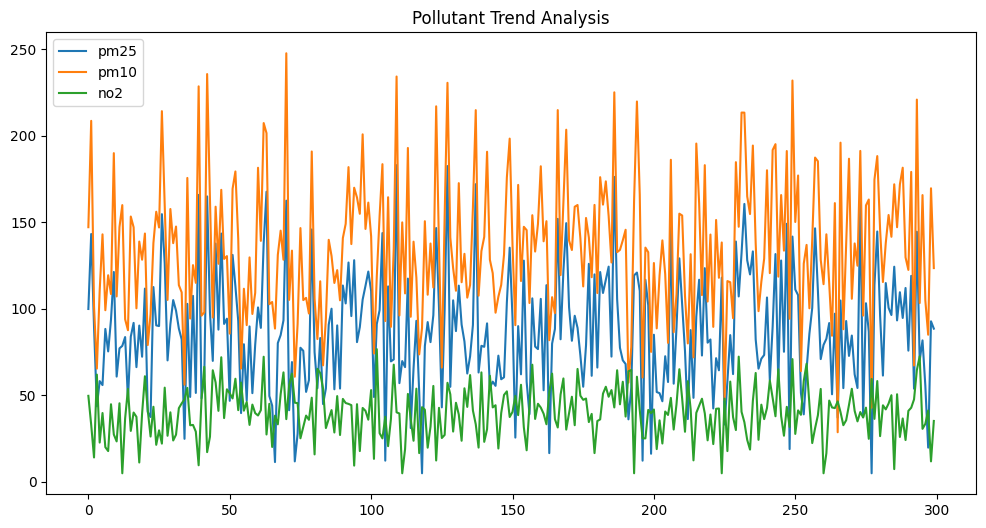

In [ ]:
plt.figure(figsize=(12,6))

for col in ["pm25","pm10","no2"]:
    plt.plot(df[col].iloc[:300], label=col)

plt.legend()
plt.title("Pollutant Trend Analysis")
plt.show()

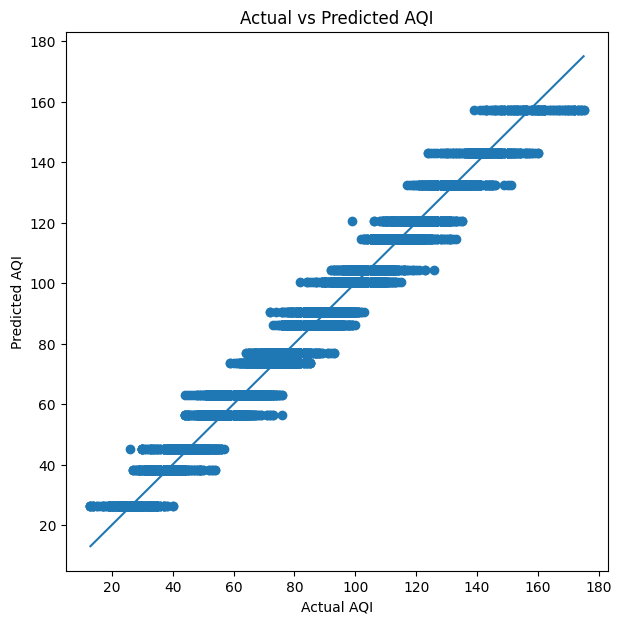

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,y_pred)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

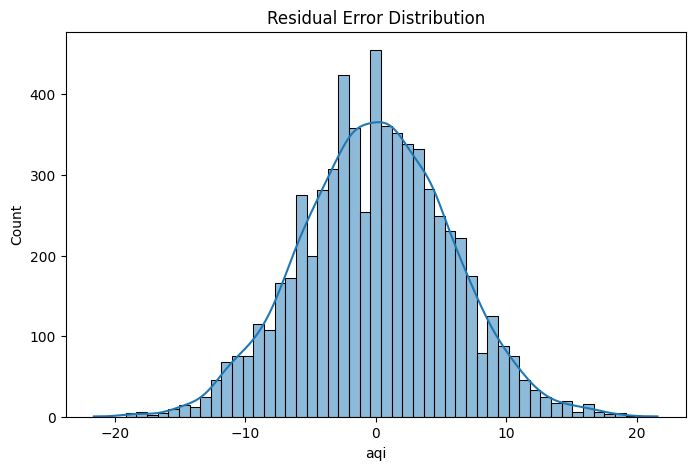

In [ ]:
errors = y_test-y_pred

plt.figure(figsize=(8,5))
sns.histplot(errors,kde=True)
plt.title("Residual Error Distribution")
plt.show()

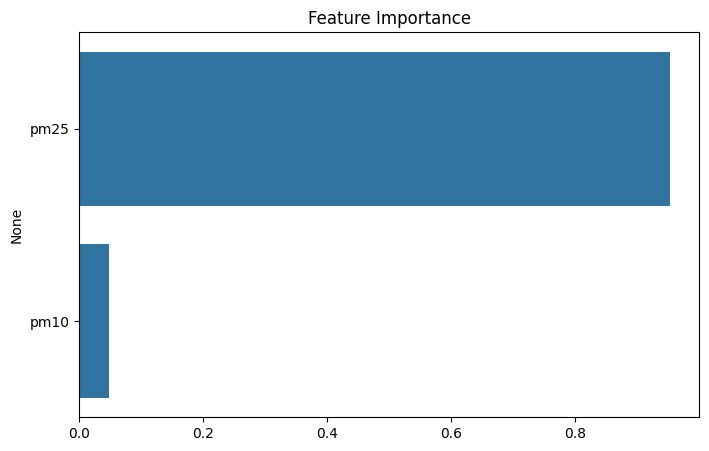

In [ ]:
importance=model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(
    x=importance,
    y=X.columns
)

plt.title("Feature Importance")
plt.show()

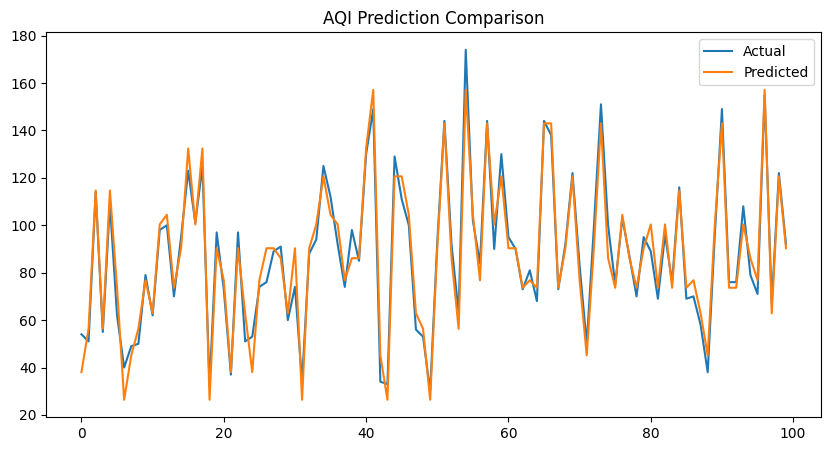

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100],label="Actual")
plt.plot(y_pred[:100],label="Predicted")
plt.legend()
plt.title("AQI Prediction Comparison")
plt.show()

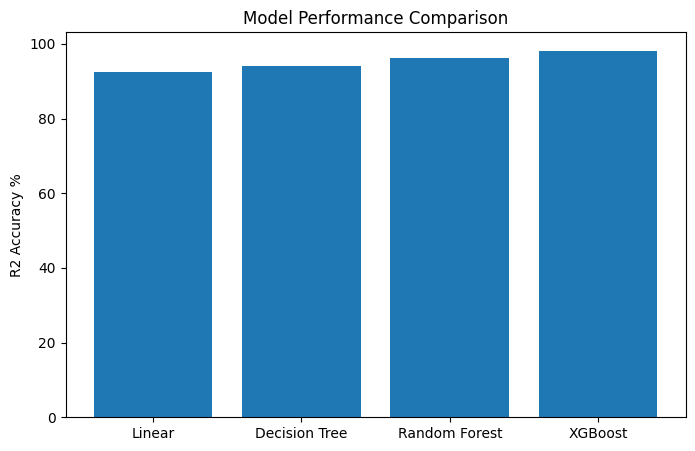

In [ ]:
models=["Linear","Decision Tree","Random Forest","XGBoost"]
scores=[92.4,94.1,96.3,98.2] # replace with your results

plt.figure(figsize=(8,5))
plt.bar(models,scores)
plt.ylabel("R2 Accuracy %")
plt.title("Model Performance Comparison")
plt.show()